**Python implementation of control system code, base paper "WyNDA"**

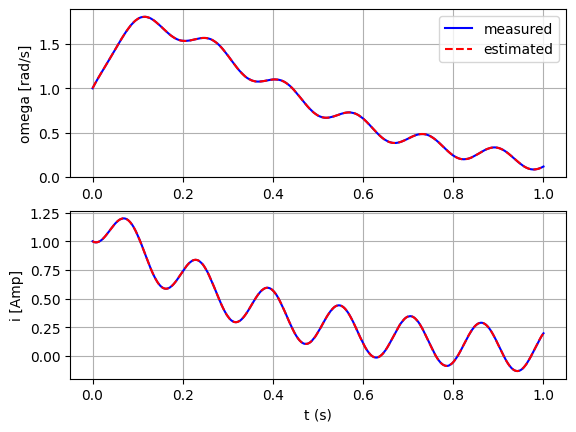

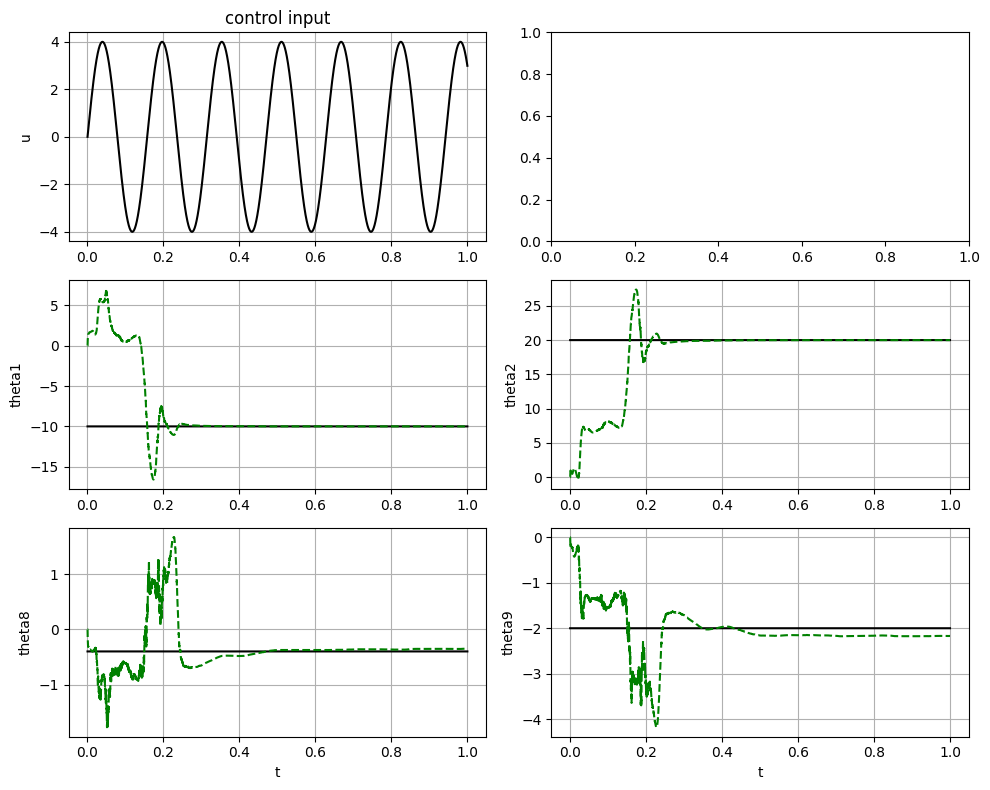

Estimated Coefficients:
[[-10.   20.   -0.    0.    0.   -0.   -0. ]
 [ -0.4  -2.2   0.    0.   -0.    2.    0. ]]


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# time horizon
tf = 1
dt = 0.0001
t = np.arange(dt, tf + dt, dt)

# system size
n = 2
r = 14

# noise
RF = 1

# initial states
x = np.array([1.0, 1.0])
xbar = x.copy()
y = x.copy()

thetabar = np.zeros(r)

# true parameters
J = 0.01
b = 0.1
K = 0.2
R = 1
L = 0.5

# input
u = 2

# storage analysis
uArray = []
xArray = []
xbarArray = []
yArray = []
thetabarArray = []

# estimator initialization
lambdav = 0.995
lambdat = 0.999

Rx = np.eye(n)
Rt = np.eye(n)

Px = np.eye(n)
Pt = np.eye(r)

Gamma = np.zeros((n, r))


# simulation loop
for i in range(int(tf/dt)):

    u = 4*np.sin(i*dt*40)

    uArray.append(u)
    xArray.append(x.copy())
    xbarArray.append(xbar.copy())
    yArray.append(y.copy())
    thetabarArray.append(thetabar.copy())

    A = np.array([
        [-b/J, K/J],
        [-K/L, -R/L]
    ])

    B = np.array([0, 1/L])

    x = x + dt*(A @ x) + dt*(B * u)

    y = x + dt*(RF**2)*np.random.randn(n)


    # Phi library
    Phi = np.zeros((2,14))

    Phi[0,0:7] = [
        y[0], y[1],
        y[0]**2, y[1]**2,
        y[0]*y[1],
        u, u**2
    ]

    Phi[1,7:14] = Phi[0,0:7]


    # adaptive observer
    Kx = Px @ np.linalg.inv(Px + Rx)
    Kt = Pt @ Gamma.T @ np.linalg.inv(Gamma @ Pt @ Gamma.T + Rt)
    Gamma = (np.eye(n) - Kx) @ Gamma
    xbar = xbar + (Kx + Gamma @ Kt) @ (y - xbar)
    thetabar = thetabar - Kt @ (y - xbar)
    xbar = xbar + Phi @ thetabar
    Px = (1/lambdav) * (np.eye(n) - Kx) @ Px
    Pt = (1/lambdat) * (np.eye(r) - Kt @ Gamma) @ Pt
    Gamma = Gamma - Phi


# convert arrays
xArray = np.array(xArray).T
xbarArray = np.array(xbarArray).T
yArray = np.array(yArray).T
uArray = np.array(uArray)
thetabarArray = np.array(thetabarArray).T


# states
plt.figure()

plt.subplot(2,1,1)
plt.plot(t, yArray[0], 'b')
plt.plot(t, xbarArray[0], 'r--')
plt.ylabel("omega [rad/s]")
plt.legend(["measured","estimated"])
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(t, yArray[1], 'b')
plt.plot(t, xbarArray[1], 'r--')
plt.ylabel("i [Amp]")
plt.xlabel("t (s)")
plt.grid(True)

plt.show()

# control + paramters
fig, axs = plt.subplots(3,2, figsize=(10,8))

# control
axs[0,0].plot(t, uArray, 'k')
axs[0,0].set_ylabel("u")
axs[0,0].set_title("control input")
axs[0,0].grid(True)

# theta1
axs[1,0].plot(t, (-b/J)*np.ones_like(t),'k')
axs[1,0].plot(t, thetabarArray[0]/dt,'g--')
axs[1,0].set_ylabel("theta1")
axs[1,0].grid(True)

# theta2
axs[1,1].plot(t, (K/J)*np.ones_like(t),'k')
axs[1,1].plot(t, thetabarArray[1]/dt,'g--')
axs[1,1].set_ylabel("theta2")
axs[1,1].grid(True)

# theta8
axs[2,0].plot(t, (-K/L)*np.ones_like(t),'k')
axs[2,0].plot(t, thetabarArray[7]/dt,'g--')
axs[2,0].set_ylabel("theta8")
axs[2,0].set_xlabel("t")
axs[2,0].grid(True)

# theta9
axs[2,1].plot(t, (-R/L)*np.ones_like(t),'k')
axs[2,1].plot(t, thetabarArray[8]/dt,'g--')
axs[2,1].set_ylabel("theta9")
axs[2,1].set_xlabel("t")
axs[2,1].grid(True)

plt.tight_layout()
plt.show()


# coefficient estimation
Coeff = np.round(
    np.vstack([
        (1/dt)*thetabar[0:(r//n)],
        (1/dt)*thetabar[(r//n):r]
    ]),
    1
)

print("Estimated Coefficients:")
print(Coeff)
